<a href="https://colab.research.google.com/github/Kommmi/Quantum-Dynamical-Systems/blob/main/Tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf Quantum-Dynamical-Systems
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Quantum-Dynamical-Systems.git

# Move into the repo
%cd Quantum-Dynamical-Systems

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gqs.states import Initial_state, rho_single_spin, Reduced_state_single_site
from gqs.dynamics import Hamiltonian_QK, floquet_operator_from_H
from gqs.distances import Quantum_EMD, Psi_Dist, bures_distance
from gqs.gqs import GQS_Bloch_Sphere_chi, GQS_Bloch_Sphere_chi_plotly
from gqs.perturbations import perturb_theta_phi_isotropic
from gqs.gamma import Avg_separation_rate_local, Compare_distances_QKT, Avg_separation_QKT
from gqs.stats import period_statistics_summary
from gqs.plotsCompare import plot_gqs_and_rho_before_after_kick, Plot_Avg_Separation

In [9]:
dhilbert,nqubit = 2, 3
#___________Global Initial State___________
thet0,phi0 = np.pi/2, np.pi/2
Psi_0 = Initial_state(nqubit, thet0, phi0)
#__________Perturbed Initial State___________
Psi_p, thet_p, phi_p = perturb_theta_phi_isotropic(nqubit, thet0, phi0, angle_sigma=0.1)
print("Fubini-Study Distance between them", Psi_Dist(Psi_0,Psi_p))

eps = 0.2
system_site = 0
N_traj,N_kicks = 10, 200

Fubini-Study Distance between them 0.059444929654054984


/content/Quantum-Dynamical-Systems/gqs/distances.py:109: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sqrt_rho = sqrtm(rho)
/content/Quantum-Dynamical-Systems/gqs/distances.py:115: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sqrt_A = sqrtm(A)


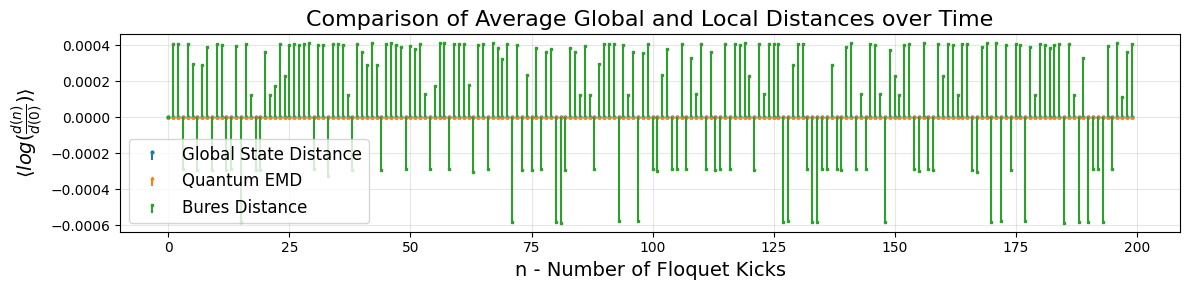

In [10]:
# Constructing the Hamiltonian and Floquet operator - 3 qubit Quantum kicked top
#___________Hamiltonian and Floquet operator___________
tau,kappa,hbar=1.0,0,1.0
order="free_then_kick"
H1, H2 = Hamiltonian_QK(tau, kappa, nqubit)
U_F = floquet_operator_from_H(H1, H2, tau,hbar,order)

data_dist=Avg_separation_QKT(dhilbert,nqubit,system_site,U_F,thet0,phi0,eps,N_traj,N_kicks)
Plot_Avg_Separation(data_dist, N_kicks)

In [19]:
ln_dl_GQS =data_dist['ln_avg_dist_L']
df,_ = period_statistics_summary(ln_dl_GQS)
display(df)

,quantity,value
0,dominant_period,2.000000e+01
1,average_per_period,-1.224593e-11
2,variance_per_period,4.260881e-23
3,average_growth_per_period,1.011402e-11
4,average_relaxation_per_period,1.021885e-11
5,directional_asymmetry,-5.155620e-03


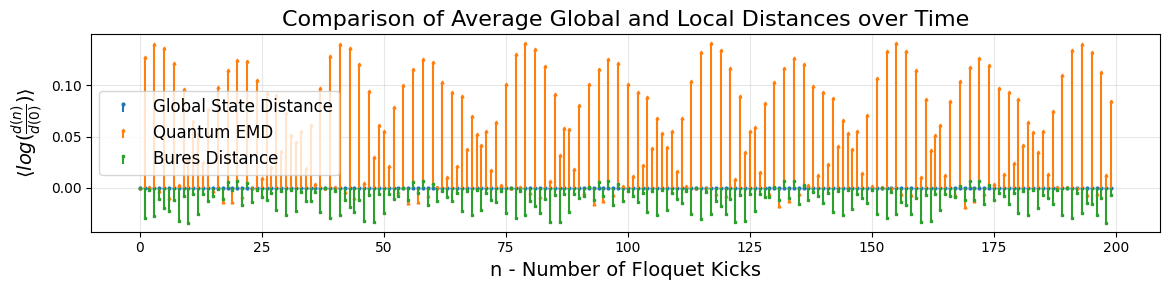

In [11]:
# Constructing the Hamiltonian and Floquet operator - 3 qubit Quantum kicked top
#___________Hamiltonian and Floquet operator___________
tau,kappa,hbar=1.0,0.5,1.0
order="free_then_kick"
H1, H2 = Hamiltonian_QK(tau, kappa, nqubit)
U_F = floquet_operator_from_H(H1, H2, tau,hbar,order)

data_dist2=Avg_separation_QKT(dhilbert,nqubit,system_site,U_F,thet0,phi0,eps,N_traj,N_kicks)
Plot_Avg_Separation(data_dist2, N_kicks)

In [18]:
ln_dl_GQS =data_dist2['ln_avg_dist_L']
df,_ = period_statistics_summary(ln_dl_GQS)
display(df)

,quantity,value
0,dominant_period,36.000000
1,average_per_period,0.053825
2,variance_per_period,0.002557
3,average_growth_per_period,0.093362
4,average_relaxation_per_period,0.089060
5,directional_asymmetry,0.023579


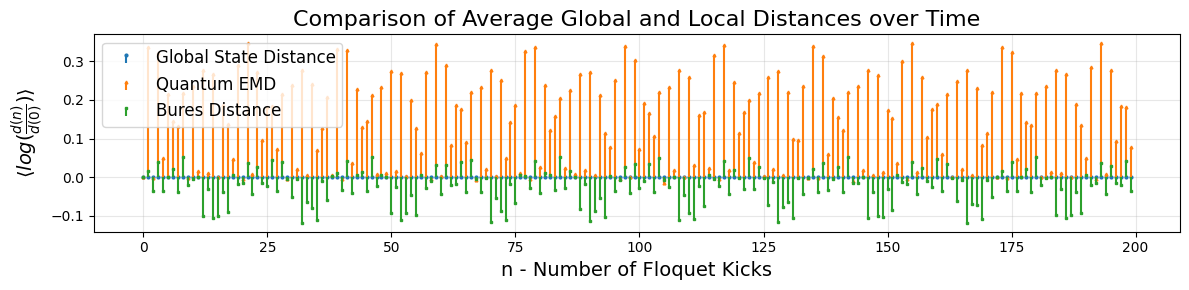

In [12]:
# Constructing the Hamiltonian and Floquet operator - 3 qubit Quantum kicked top
#___________Hamiltonian and Floquet operator___________
tau,kappa,hbar=1.0,1.,1.0
order="free_then_kick"
H1, H2 = Hamiltonian_QK(tau, kappa, nqubit)
U_F = floquet_operator_from_H(H1, H2, tau,hbar,order)

data_dist3=Avg_separation_QKT(dhilbert,nqubit,system_site,U_F,thet0,phi0,eps,N_traj,N_kicks)
Plot_Avg_Separation(data_dist3, N_kicks)

In [17]:
ln_dl_GQS =data_dist3['ln_avg_dist_L']
df,_ = period_statistics_summary(ln_dl_GQS)
display(df)

,quantity,value
0,dominant_period,18.000000
1,average_per_period,0.143630
2,variance_per_period,0.013310
3,average_growth_per_period,0.207600
4,average_relaxation_per_period,0.204141
5,directional_asymmetry,0.008401


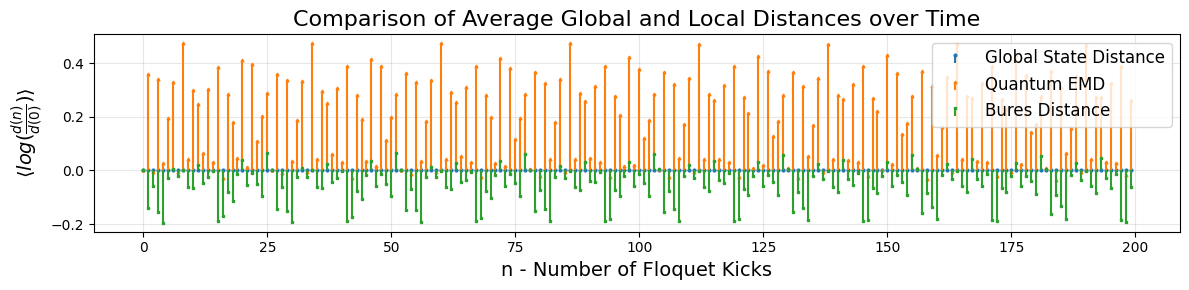

In [13]:
# Constructing the Hamiltonian and Floquet operator - 3 qubit Quantum kicked top
#___________Hamiltonian and Floquet operator___________
tau,kappa,hbar=1.0,1.5,1.0
order="free_then_kick"
H1, H2 = Hamiltonian_QK(tau, kappa, nqubit)
U_F = floquet_operator_from_H(H1, H2, tau,hbar,order)

data_dist4=Avg_separation_QKT(dhilbert,nqubit,system_site,U_F,thet0,phi0,eps,N_traj,N_kicks)
Plot_Avg_Separation(data_dist4, N_kicks)

In [16]:
ln_dl_GQS =data_dist4['ln_avg_dist_L']
df,_ = period_statistics_summary(ln_dl_GQS)
display(df)

,quantity,value
0,dominant_period,26.000000
1,average_per_period,0.190745
2,variance_per_period,0.024651
3,average_growth_per_period,0.274444
4,average_relaxation_per_period,0.274121
5,directional_asymmetry,0.000589


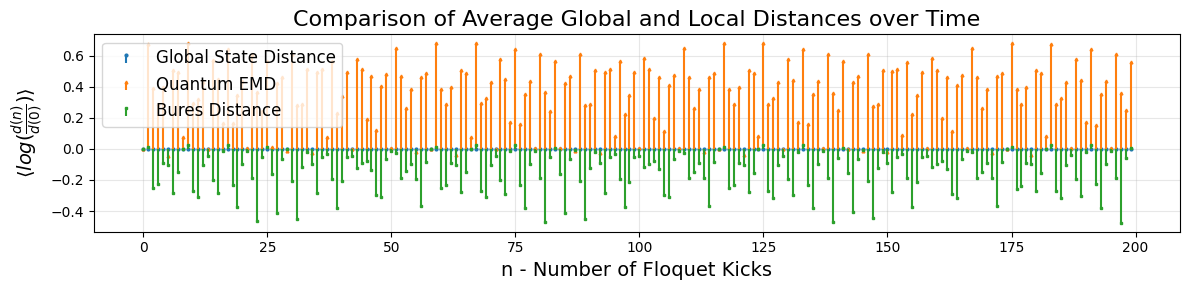

In [14]:

#___________Hamiltonian and Floquet operator___________
tau,kappa,hbar=1.0,2.5,1.0
order="free_then_kick"
H1, H2 = Hamiltonian_QK(tau, kappa, nqubit)
# Constructing the Hamiltonian and Floquet operator - 3 qubit Quantum kicked top
U_F = floquet_operator_from_H(H1, H2, tau,hbar,order)

data_dist5=Avg_separation_QKT(dhilbert,nqubit,system_site,U_F,thet0,phi0,eps,N_traj,N_kicks)
Plot_Avg_Separation(data_dist5, N_kicks)

In [15]:
ln_dl_GQS =data_dist5['ln_avg_dist_L']
df,_ = period_statistics_summary(ln_dl_GQS)
display(df)

,quantity,value
0,dominant_period,58.000000
1,average_per_period,0.342751
2,variance_per_period,0.045554
3,average_growth_per_period,0.313912
4,average_relaxation_per_period,0.330636
5,directional_asymmetry,-0.025946
